In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. SETUP & DATA LOADING
# Load the dataset
df = pd.read_csv('/content/savanna_fibre_clean.csv')

# Preprocessing: Convert Date to datetime objects and sort chronologically
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

# Set aesthetic style for all charts
sns.set_theme(style="whitegrid")

# 2. CALCULATE KEY METRICS & EXECUTIVE SUMMARY

In [17]:
# CALCULATE KEY METRICS
total_revenue = df['Payment_UGX'].sum()
total_new_customers = df['New_Customers'].sum()
total_renewals = df['Renewals'].sum()

# Growth metrics
starting_count = df['total_customers'].iloc[0]
ending_count = df['total_customers'].iloc[-1]
net_growth = ending_count - starting_count
growth_pct = (net_growth / starting_count) * 100

# Package performance
revenue_by_pkg = df.groupby('Package')['Payment_UGX'].sum().sort_values(ascending=False)
onboarding_by_pkg = df.groupby('Package')['New_Customers'].sum().sort_values(ascending=False)

# Print Summary Report to Console
print("-" * 40)
print("SAVANNA FIBRE EXECUTIVE SUMMARY")
print("-" * 40)
print(f"Total Revenue:            UGX {total_revenue:,.0f}")
print(f"Total New Customers:      {total_new_customers:,}")
print(f"Total Renewals:           {total_renewals:,}")
print(f"Final Customer Base:      {ending_count:,}")
print(f"Net Growth:               {net_growth:+} ({growth_pct:.2f}%)वरुन")
print(f"Avg Daily Revenue:        UGX {df['Payment_UGX'].mean():,.2f}")
print("-" * 40)
print(f"Top Revenue Package:      {revenue_by_pkg.index[0]}")
print(f"Top Acquisition Package:  {onboarding_by_pkg.index[0]}")
print("-" * 40)

----------------------------------------
SAVANNA FIBRE EXECUTIVE SUMMARY
----------------------------------------
Total Revenue:            UGX 111,301,000
Total New Customers:      16,358
Total Renewals:           116,347
Final Customer Base:      409
Net Growth:               +37 (9.95%)वरुन
Avg Daily Revenue:        UGX 304,934.25
----------------------------------------
Top Revenue Package:      Twiga_72K
Top Acquisition Package:  Ndovu_253K
----------------------------------------


# 3. GENERATE VISUALIZATIONS

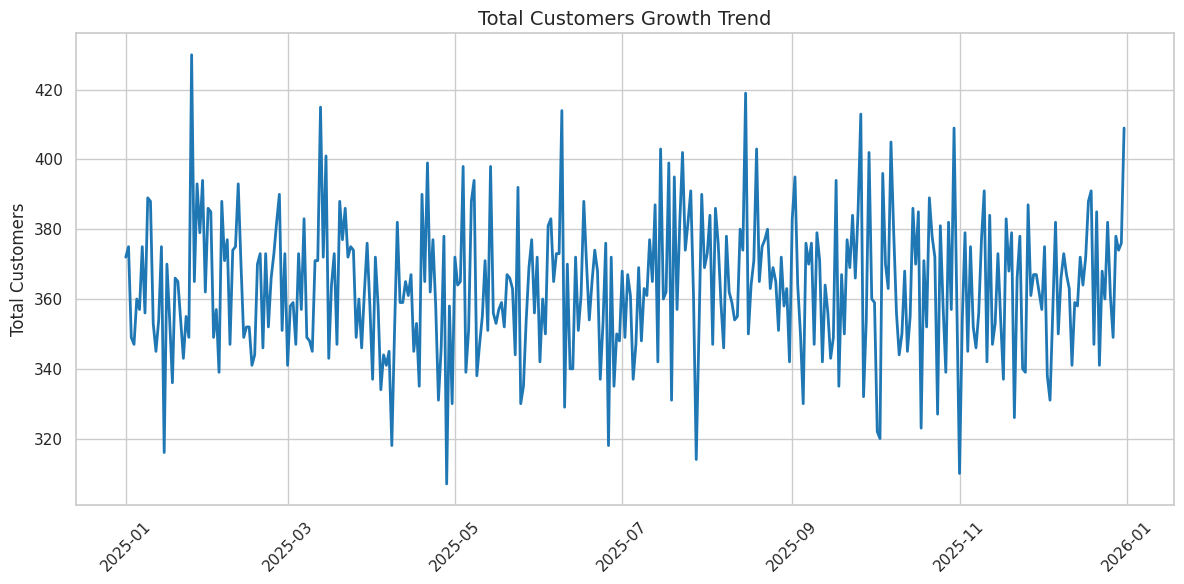

In [18]:
# Chart 1: Total Customer Growth
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['total_customers'], color='tab:blue', linewidth=2)
plt.title('Total Customers Growth Trend', fontsize=14)
plt.ylabel('Total Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('1_customer_growth.png')
plt.show()

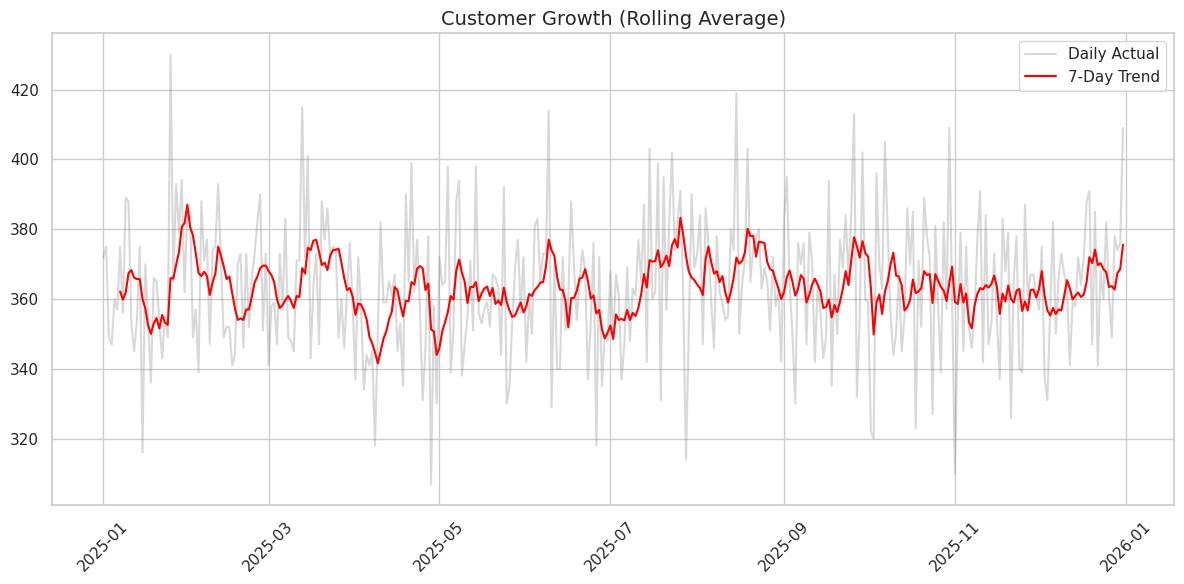

In [19]:
# Chart 2: 7-Day Rolling Average (Smoothing)
df['total_customers_7d_avg'] = df['total_customers'].rolling(window=7).mean()
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['total_customers'], alpha=0.3, color='gray', label='Daily Actual')
plt.plot(df['Date'], df['total_customers_7d_avg'], color='red', label='7-Day Trend')
plt.title('Customer Growth (Rolling Average)', fontsize=14)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('2_growth_smoothed.png')
plt.show()

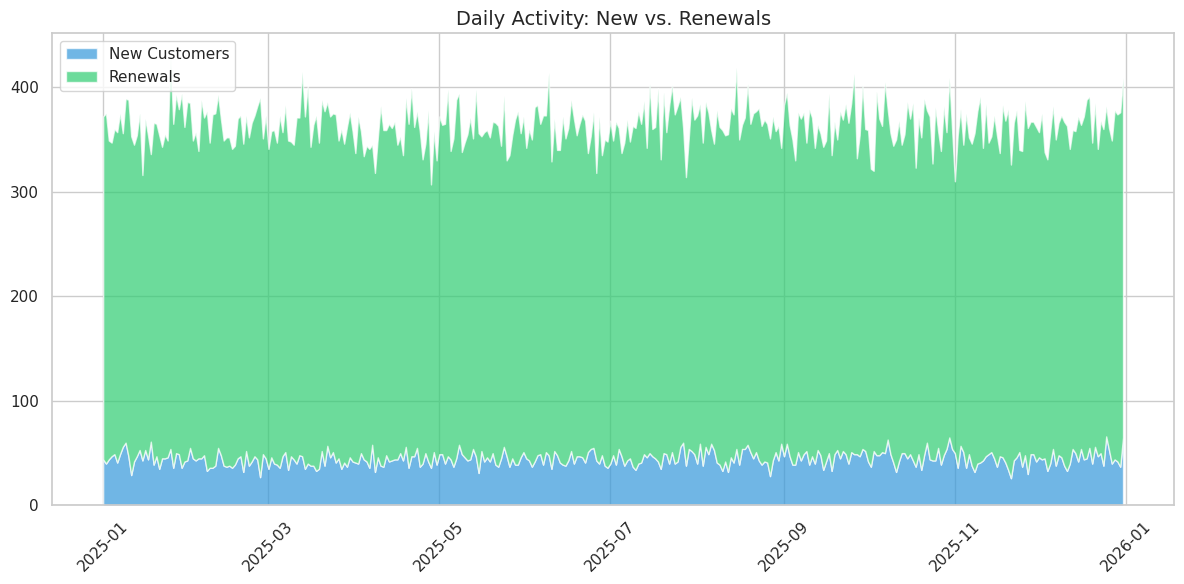

In [20]:
# Chart 3: Stacked Activity Area
plt.figure(figsize=(12, 6))
plt.stackplot(df['Date'], df['New_Customers'], df['Renewals'],
              labels=['New Customers', 'Renewals'], alpha=0.7, colors=['#3498db', '#2ecc71'])
plt.title('Daily Activity: New vs. Renewals', fontsize=14)
plt.legend(loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('3_activity_composition.png')
plt.show()

/tmp/ipykernel_8844/3954412492.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=onboarding_by_pkg.reset_index(), x='Package', y='New_Customers', palette='viridis')


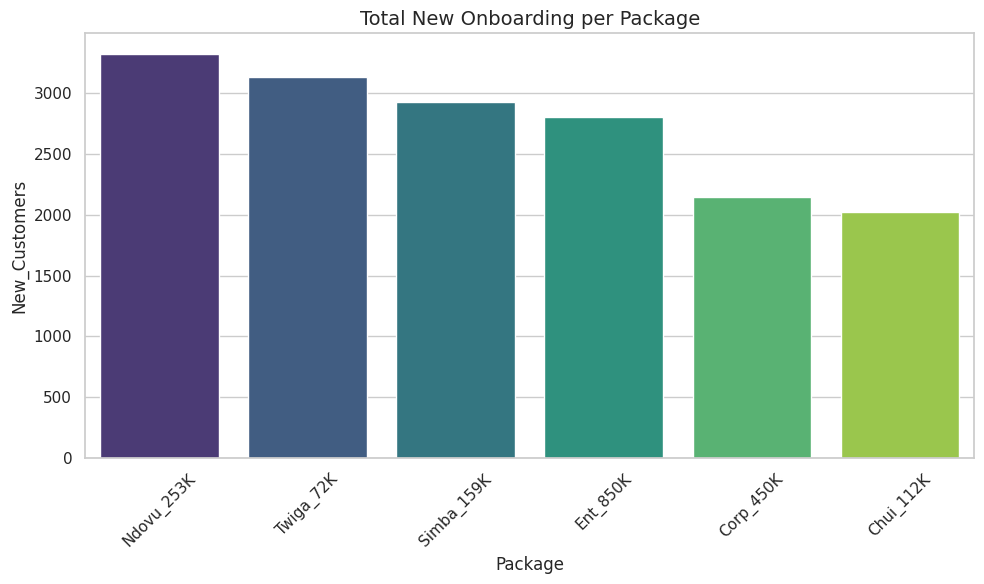

In [21]:
# Chart 4: New Customers by Package (Bar)
plt.figure(figsize=(10, 6))
sns.barplot(data=onboarding_by_pkg.reset_index(), x='Package', y='New_Customers', palette='viridis')
plt.title('Total New Onboarding per Package', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('4_acquisition_by_package.png')
plt.show()

/tmp/ipykernel_8844/1906370219.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Package', y='Renewals', palette='Set2')


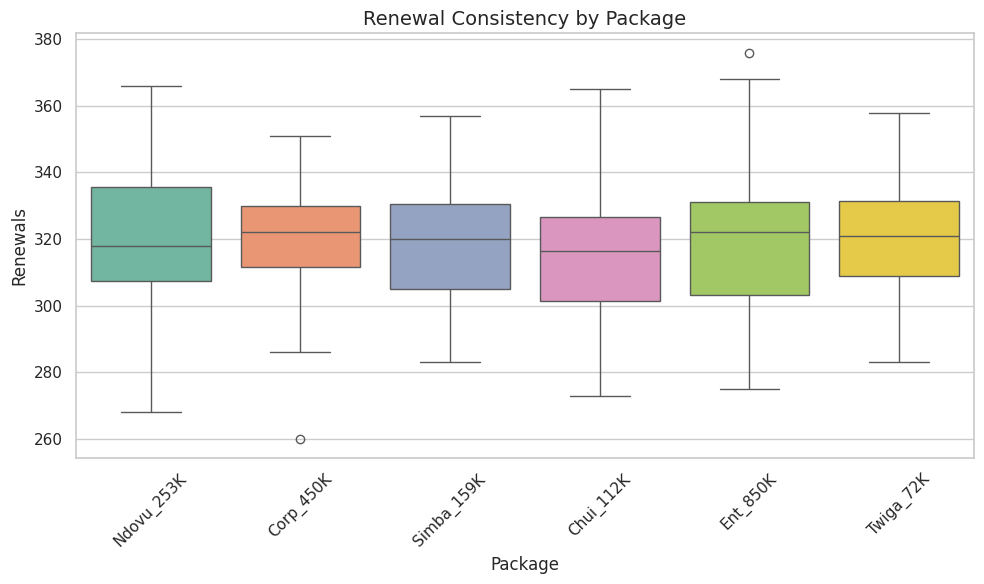

In [22]:
# Chart 5: Renewal Consistency (Box Plot)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Package', y='Renewals', palette='Set2')
plt.title('Renewal Consistency by Package', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('5_renewal_consistency.png')
plt.show()

/tmp/ipykernel_8844/3272387324.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Package', y='New_Customers', palette='muted', inner='quartile')


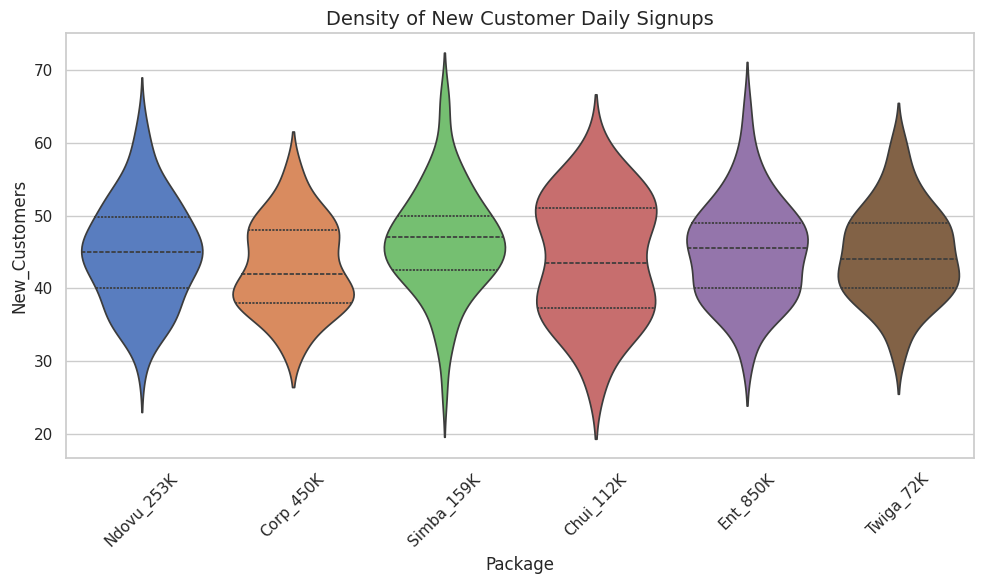

In [23]:
# Chart 6: New Customer Density (Violin Plot)
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='Package', y='New_Customers', palette='muted', inner='quartile')
plt.title('Density of New Customer Daily Signups', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('6_onboarding_density.png')
plt.show()

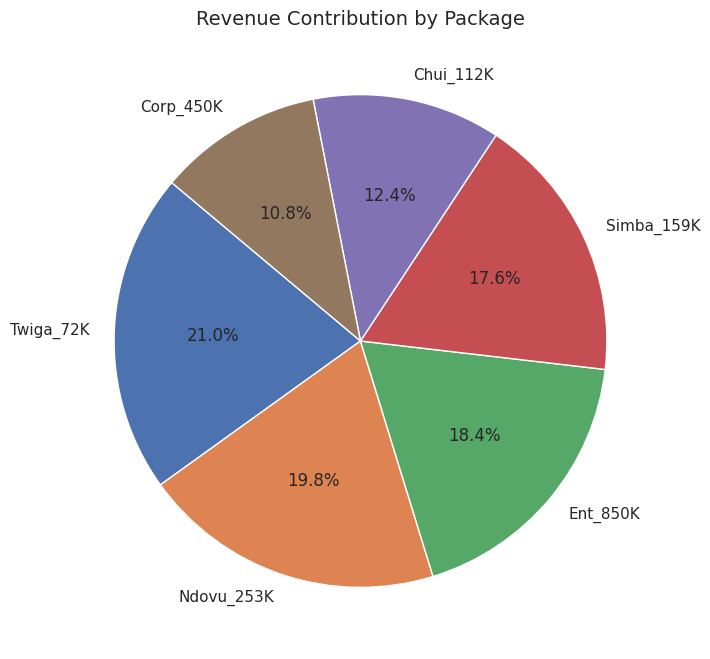

In [24]:
# Chart 7: Revenue Share (Pie Chart)
plt.figure(figsize=(8, 8))
plt.pie(revenue_by_pkg, labels=revenue_by_pkg.index, autopct='%1.1f%%', startangle=140)
plt.title('Revenue Contribution by Package', fontsize=14)
plt.savefig('7_revenue_share_pie.png')
plt.show()

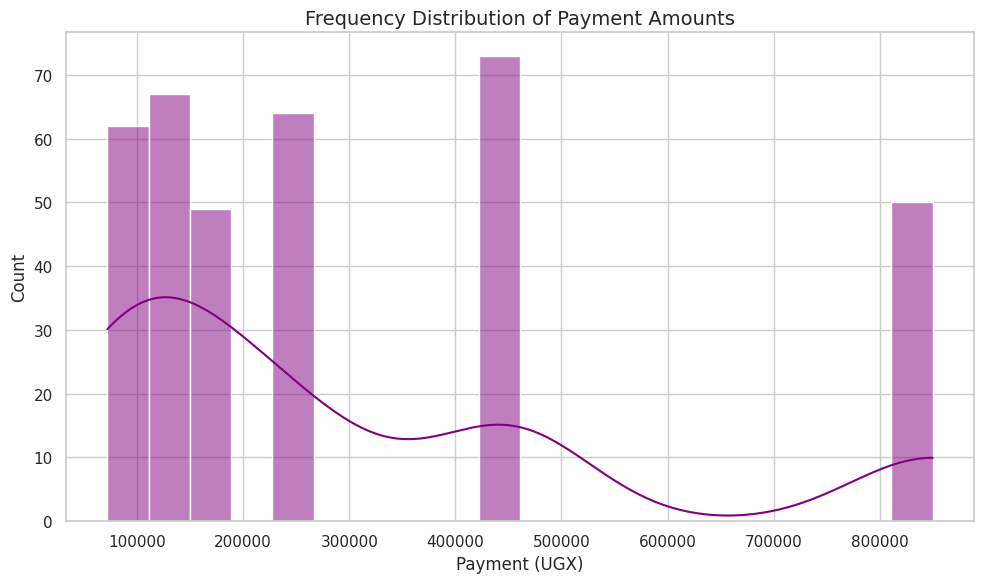

In [25]:
# Chart 8: Payment Amount Frequency (Histogram)
plt.figure(figsize=(10, 6))
sns.histplot(df['Payment_UGX'], bins=20, kde=True, color='purple')
plt.title('Frequency Distribution of Payment Amounts', fontsize=14)
plt.xlabel('Payment (UGX)')
plt.tight_layout()
plt.savefig('8_payment_distribution.png')
plt.show()

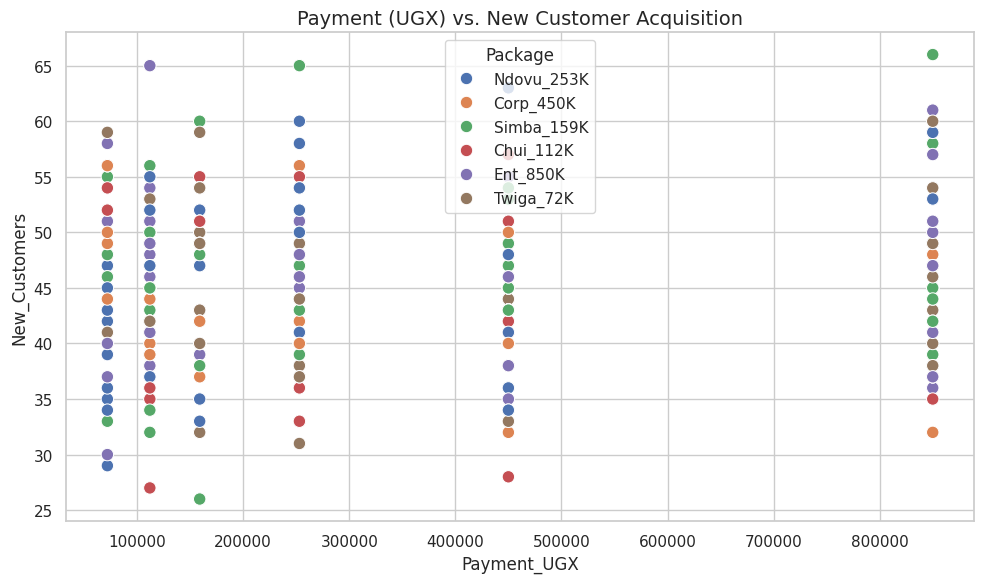

In [26]:
# Chart 9: Payment vs New Customers (Scatter)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Payment_UGX', y='New_Customers', hue='Package', s=80)
plt.title('Payment (UGX) vs. New Customer Acquisition', fontsize=14)
plt.tight_layout()
plt.savefig('9_payment_vs_new_scatter.png')
plt.show()

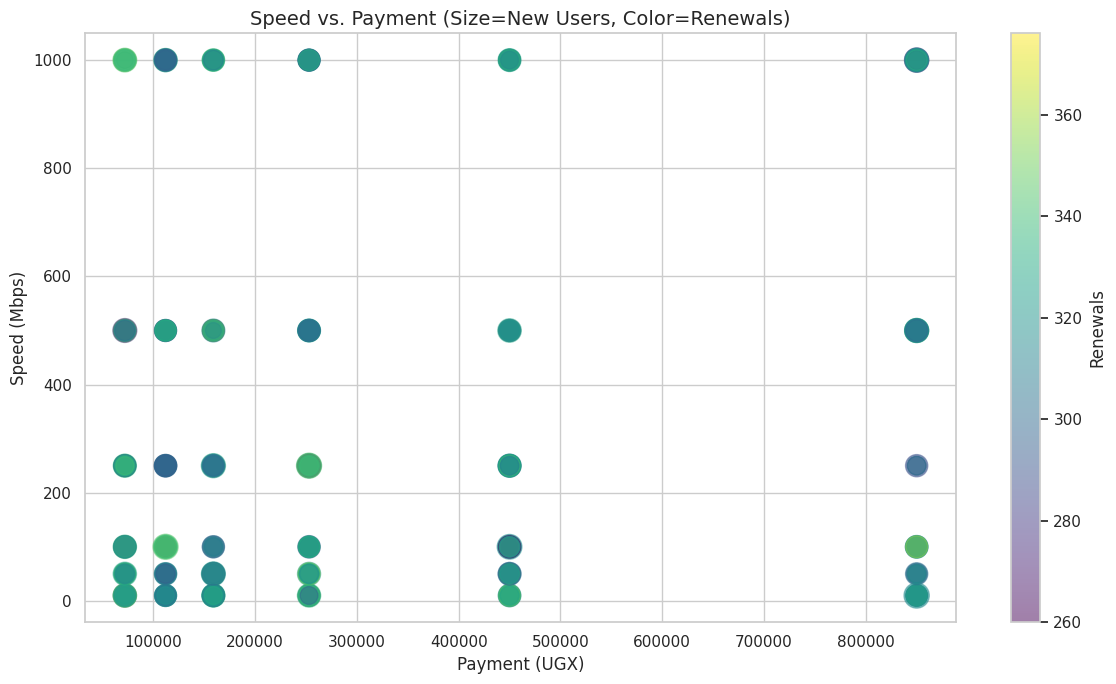

In [27]:
# Chart 10: Multi-Dimensional Bubble Analysis
plt.figure(figsize=(12, 7))
bubble = plt.scatter(df['Payment_UGX'], df['Speed_Mbps'],
                     s=df['New_Customers']*5, alpha=0.5,
                     c=df['Renewals'], cmap='viridis')
plt.colorbar(bubble, label='Renewals')
plt.title('Speed vs. Payment (Size=New Users, Color=Renewals)', fontsize=14)
plt.xlabel('Payment (UGX)')
plt.ylabel('Speed (Mbps)')
plt.tight_layout()
plt.savefig('10_bubble_performance.png')
plt.show()

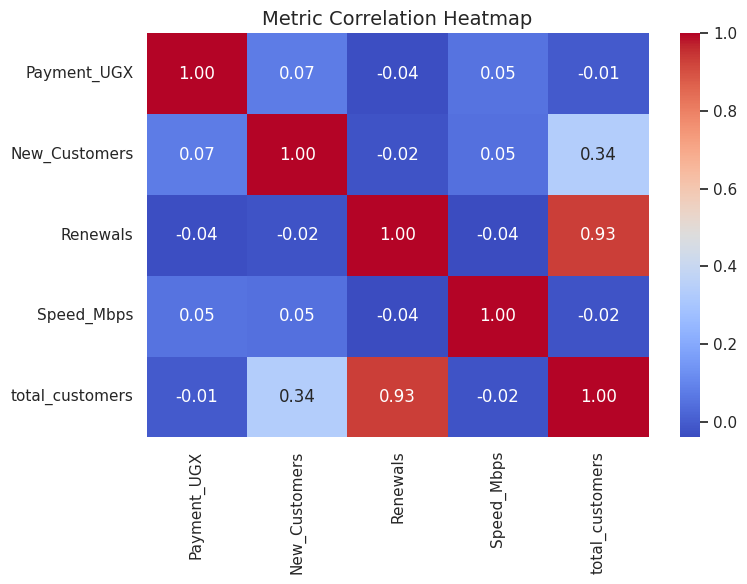

In [28]:
# Chart 11: Correlation Heatmap
plt.figure(figsize=(8, 6))
corr = df[['Payment_UGX', 'New_Customers', 'Renewals', 'Speed_Mbps', 'total_customers']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Metric Correlation Heatmap', fontsize=14)
plt.tight_layout()
plt.savefig('11_correlation_heatmap.png')
plt.show()

# 2. TIME-SERIES & TREND CHARTS

### Chart 1: Total Customers Growth Trend

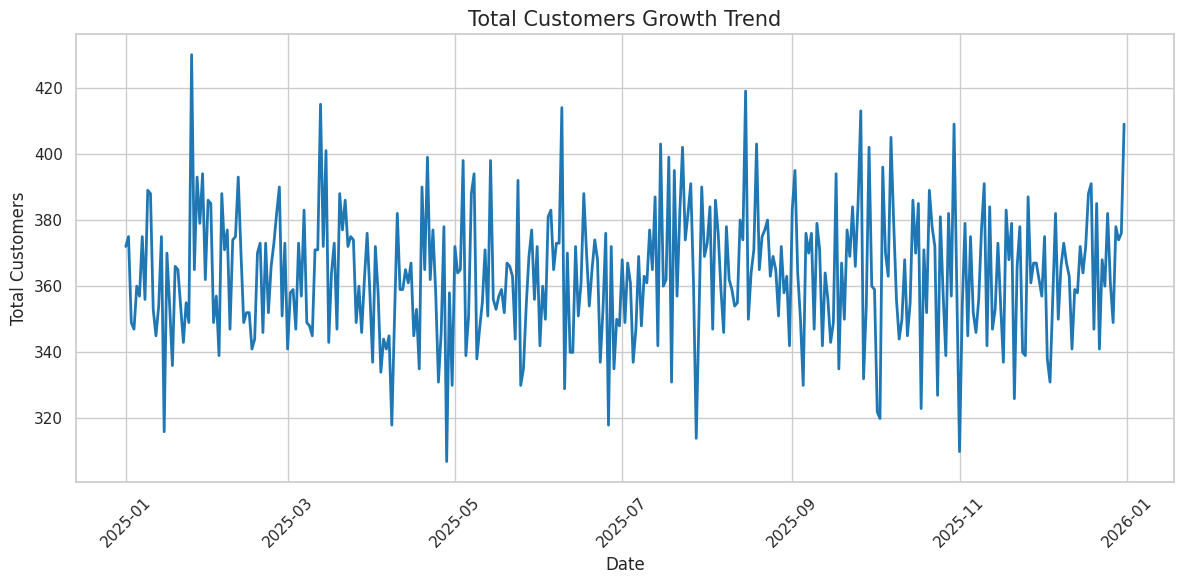

In [4]:
# Chart 1: Total Customers Over Time (Line Chart)
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['total_customers'], color='tab:blue', linewidth=2)
plt.title('Total Customers Growth Trend', fontsize=15)
plt.xlabel('Date')
plt.ylabel('Total Customers')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('1_total_customers_trend.png')
plt.show()

This line chart visualizes the total number of customers over time. It helps in understanding the overall growth trajectory of the customer base. The chart shows a general upward trend, indicating a growing customer base, but with some fluctuations.

This line chart visualizes the total number of customers over time. It helps in understanding the overall growth trajectory of the customer base.

### Chart 2: Total Customers Growth (Smoothed Trend)

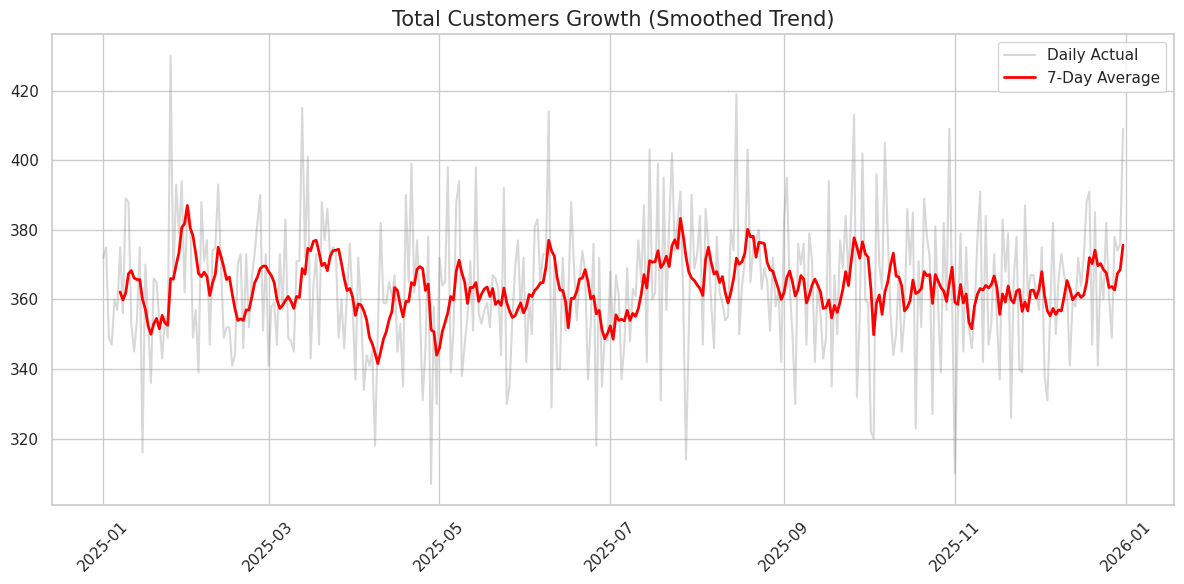

In [5]:
# Chart 2: 7-Day Rolling Average (Smoothing Noise)
df['total_customers_7d_avg'] = df['total_customers'].rolling(window=7).mean()
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['total_customers'], alpha=0.3, label='Daily Actual', color='gray')
plt.plot(df['Date'], df['total_customers_7d_avg'], color='red', label='7-Day Average', linewidth=2)
plt.title('Total Customers Growth (Smoothed Trend)', fontsize=15)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('2_total_customers_rolling.png')
plt.show()

This chart overlays a 7-day rolling average on the daily total customer count. The rolling average helps to smooth out daily fluctuations, revealing the underlying customer growth trend more clearly. The smoothed red line provides a clearer view of the consistent growth trend despite daily variations.

This chart overlays a 7-day rolling average on the daily total customer count. The rolling average helps to smooth out daily fluctuations, revealing the underlying customer growth trend more clearly.

### Chart 3: Daily Customer Activity Composition (New vs Renewals)

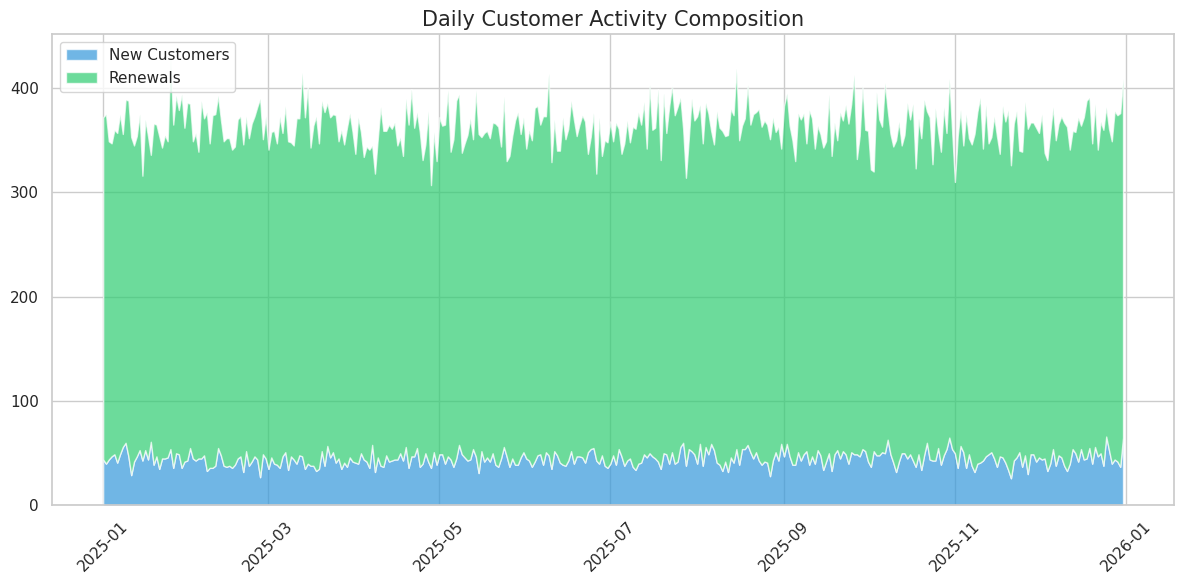

In [6]:
# Chart 3: Stacked Activity (New vs Renewals)
plt.figure(figsize=(12, 6))
plt.stackplot(df['Date'], df['New_Customers'], df['Renewals'],
              labels=['New Customers', 'Renewals'], alpha=0.7, colors=['#3498db', '#2ecc71'])
plt.title('Daily Customer Activity Composition', fontsize=15)
plt.legend(loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('3_stacked_activity.png')
plt.show()

This stacked area chart shows the daily breakdown of customer activity, distinguishing between new customer acquisitions and renewals. It highlights the contribution of each segment to the daily customer changes. We can observe that renewals consistently form a larger portion of daily activity compared to new customer acquisitions.

This stacked area chart shows the daily breakdown of customer activity, distinguishing between new customer acquisitions and renewals. It highlights the contribution of each segment to the daily customer changes.

# 3. CATEGORICAL & COMPARISON CHARTS

### Chart 4: Total New Customers Acquired per Package

/tmp/ipykernel_8844/3478048336.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=package_new, x='Package', y='New_Customers', palette='viridis')


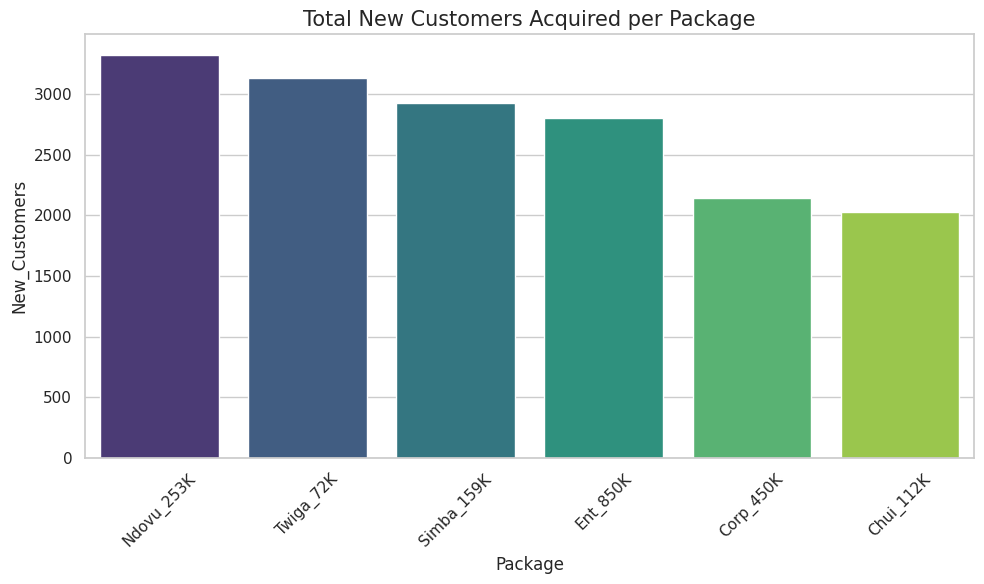

In [7]:
# Chart 4: New Customers per Package (Bar Chart)
plt.figure(figsize=(10, 6))
package_new = df.groupby('Package')['New_Customers'].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=package_new, x='Package', y='New_Customers', palette='viridis')
plt.title('Total New Customers Acquired per Package', fontsize=15)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('4_new_customers_bar.png')
plt.show()

This bar chart displays the total number of new customers acquired for each service package. It helps identify which packages are most effective in attracting new subscribers. 'Ndovu_253K' and 'Twiga_72K' appear to be the top performers in terms of new customer acquisition.

This bar chart displays the total number of new customers acquired for each service package. It helps identify which packages are most effective in attracting new subscribers.

### Chart 5: Renewal Consistency by Package

/tmp/ipykernel_8844/1592000938.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Package', y='Renewals', palette='Set2')


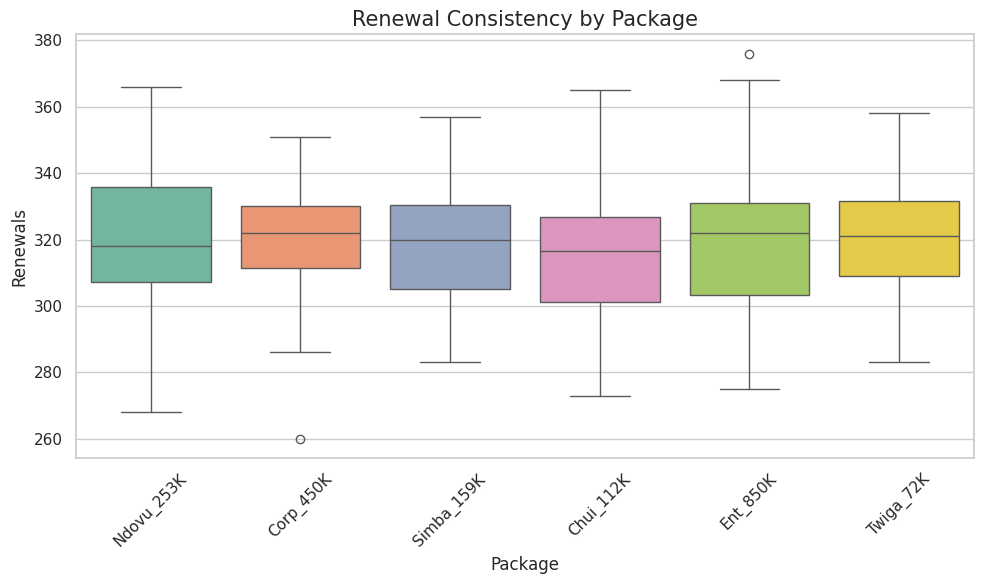

In [8]:
# Chart 5: Renewals Distribution (Box Plot)
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Package', y='Renewals', palette='Set2')
plt.title('Renewal Consistency by Package', fontsize=15)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('5_renewals_boxplot.png')
plt.show()

The box plot illustrates the distribution and consistency of renewals across different packages. It shows the median, quartiles, and outliers for daily renewals, indicating which packages have more stable or varied renewal rates. Some packages show a tighter distribution of renewals, suggesting more consistent renewal numbers, while others show wider ranges and potential outliers.

The box plot illustrates the distribution and consistency of renewals across different packages. It shows the median, quartiles, and outliers for daily renewals, indicating which packages have more stable or varied renewal rates.

### Chart 6: Density of Daily New Customer Onboarding

/tmp/ipykernel_8844/2464954607.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Package', y='New_Customers', palette='muted', inner='quartile')


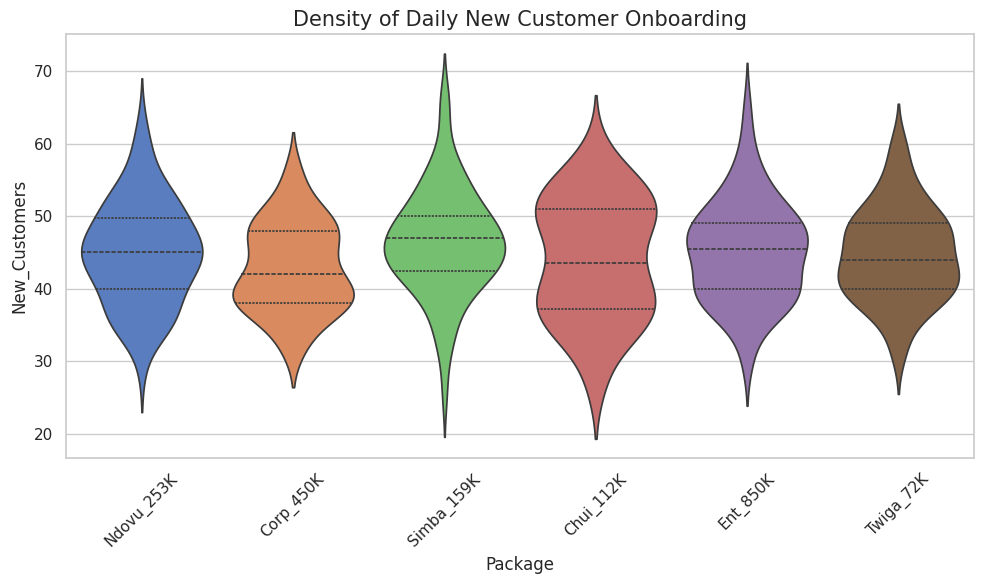

In [9]:
# Chart 6: New Customer Density (Violin Plot)
plt.figure(figsize=(10, 6))
sns.violinplot(data=df, x='Package', y='New_Customers', palette='muted', inner='quartile')
plt.title('Density of Daily New Customer Onboarding', fontsize=15)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('6_new_customers_violin.png')
plt.show()

This violin plot shows the distribution density of daily new customer sign-ups for each package. It provides insights into the typical daily onboarding volume and its variability for each package. The width of the violin indicates the frequency of observations at that level, showing where new customer numbers tend to cluster for each package.

This violin plot shows the distribution density of daily new customer sign-ups for each package. It provides insights into the typical daily onboarding volume and its variability for each package.

# 4. REVENUE & COMPOSITION CHARTS

### Chart 7: Revenue Contribution (%) by Package

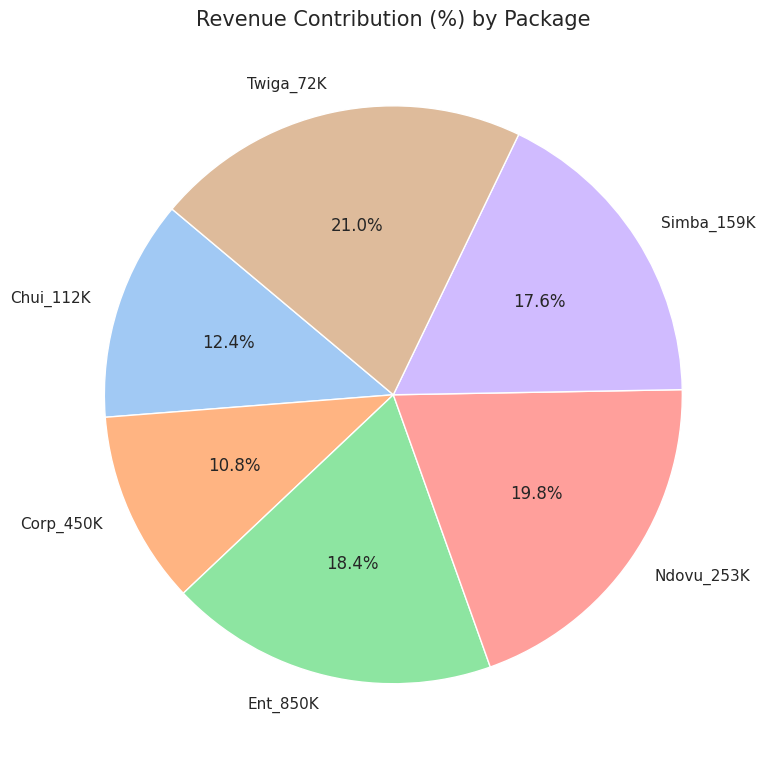

In [10]:
# Chart 7: Revenue Share per Package (Pie Chart)
plt.figure(figsize=(8, 8))
package_payments = df.groupby('Package')['Payment_UGX'].sum()
plt.pie(package_payments, labels=package_payments.index, autopct='%1.1f%%',
        startangle=140, colors=sns.color_palette('pastel'))
plt.title('Revenue Contribution (%) by Package', fontsize=15)
plt.tight_layout()
plt.savefig('7_revenue_pie.png')
plt.show()

This pie chart visualizes the proportion of total revenue generated by each service package. It quickly highlights the top-contributing packages to the overall revenue. 'Twiga_72K' and 'Ndovu_253K' are the largest contributors to total revenue, aligning with their performance in new customer acquisition.

This pie chart visualizes the proportion of total revenue generated by each service package. It quickly highlights the top-contributing packages to the overall revenue.

### Chart 8: Distribution of Payment Amounts (UGX)

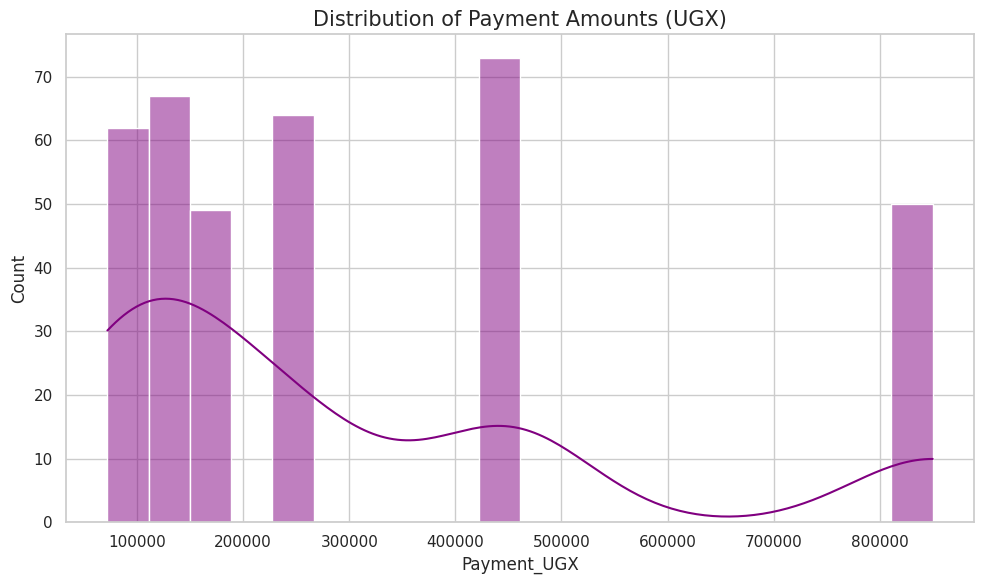

In [11]:
# Chart 8: Payment Amount Distribution (Histogram)
plt.figure(figsize=(10, 6))
sns.histplot(df['Payment_UGX'], bins=20, kde=True, color='purple')
plt.title('Distribution of Payment Amounts (UGX)', fontsize=15)
plt.tight_layout()
plt.savefig('8_payment_hist.png')
plt.show()

This histogram with a Kernel Density Estimate (KDE) shows the frequency distribution of payment amounts made by customers. It helps understand the typical payment ranges and any common payment tiers. The distribution indicates distinct peaks, suggesting popular payment tiers among customers.

This histogram with a Kernel Density Estimate (KDE) shows the frequency distribution of payment amounts made by customers. It helps understand the typical payment ranges and any common payment tiers.

# 5. RELATIONSHIP & CORRELATION CHARTS

### Chart 9: Correlation: Payment (UGX) vs. New Customer Acquisition

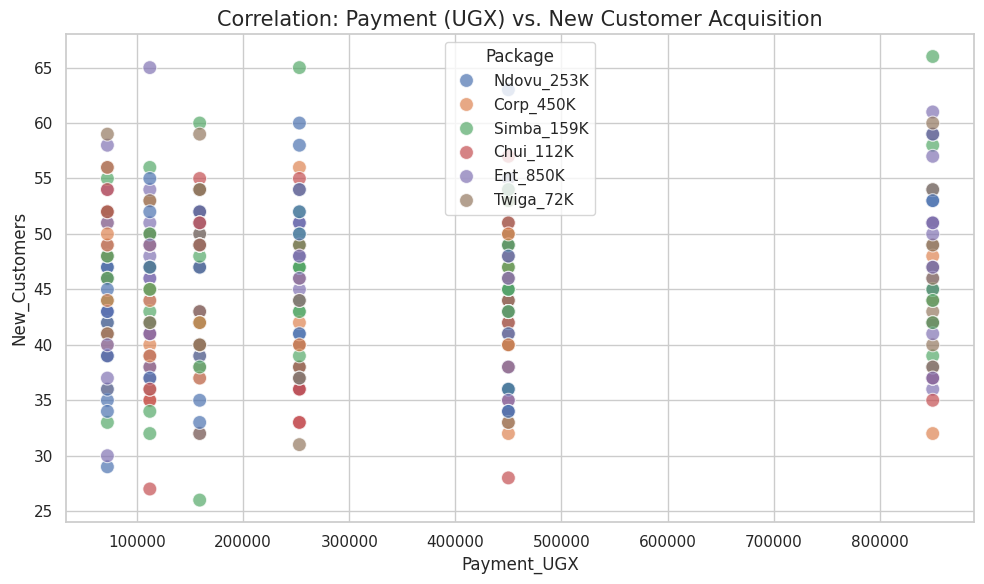

In [12]:
# Chart 9: Payment vs New Customers (Scatter Plot)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Payment_UGX', y='New_Customers', hue='Package', s=100, alpha=0.7)
plt.title('Correlation: Payment (UGX) vs. New Customer Acquisition', fontsize=15)
plt.tight_layout()
plt.savefig('9_payment_vs_new_scatter.png')
plt.show()

This scatter plot explores the relationship between payment amounts and new customer acquisitions, with different packages distinguished by color. It helps identify if higher payment packages correlate with more new customers or if certain packages are better for acquisition. We can observe clusters of new customers around specific payment points, often corresponding to different packages.

This scatter plot explores the relationship between payment amounts and new customer acquisitions, with different packages distinguished by color. It helps identify if higher payment packages correlate with more new customers or if certain packages are better for acquisition.

### Chart 10: Speed vs. Payment (Size=New Customers, Color=Renewals)

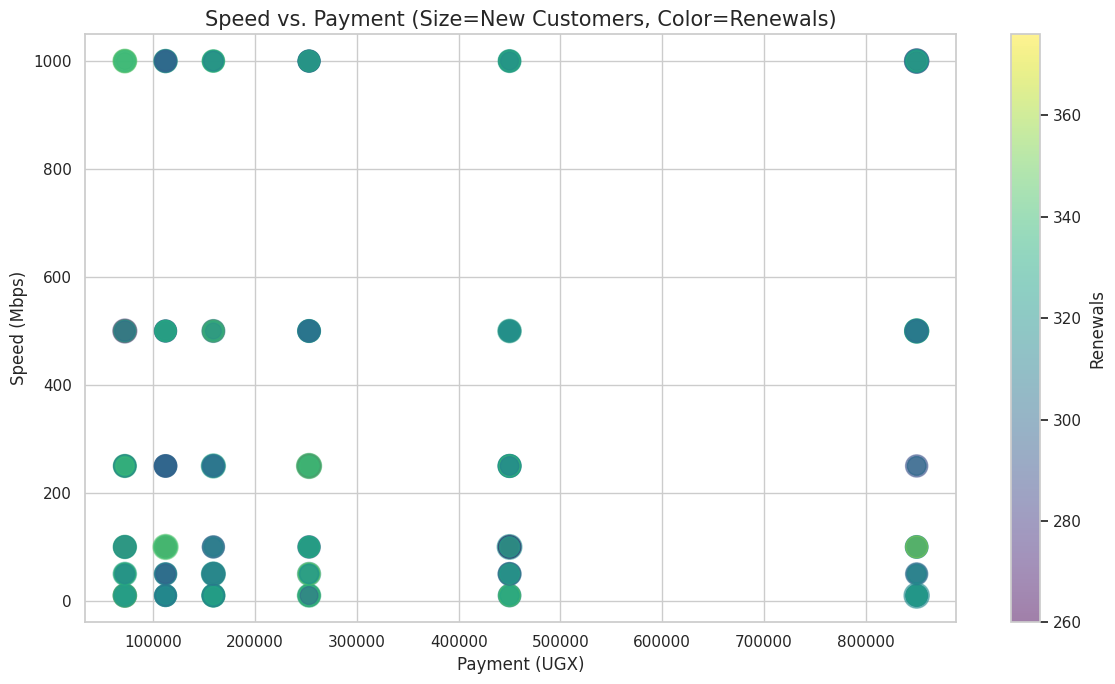

In [13]:
# Chart 10: Multi-Dimensional Bubble Chart (Speed vs Payment)
plt.figure(figsize=(12, 7))
bubble = plt.scatter(df['Payment_UGX'], df['Speed_Mbps'],
                     s=df['New_Customers']*5, # Size based on onboarding
                     alpha=0.5, c=df['Renewals'], cmap='viridis')
plt.colorbar(bubble, label='Renewals')
plt.title('Speed vs. Payment (Size=New Customers, Color=Renewals)', fontsize=15)
plt.xlabel('Payment (UGX)')
plt.ylabel('Speed (Mbps)')
plt.tight_layout()
plt.savefig('10_bubble_analysis.png')
plt.show()

This multi-dimensional bubble chart visualizes the relationship between internet speed and payment amount. The size of the bubble represents the number of new customers, and the color indicates the number of renewals, offering a rich view of package performance. This chart allows for a comprehensive assessment of how speed, payment, new customers, and renewals interact across different offerings.

This multi-dimensional bubble chart visualizes the relationship between internet speed and payment amount. The size of the bubble represents the number of new customers, and the color indicates the number of renewals, offering a rich view of package performance.

### Chart 11: Metric Correlation Heatmap

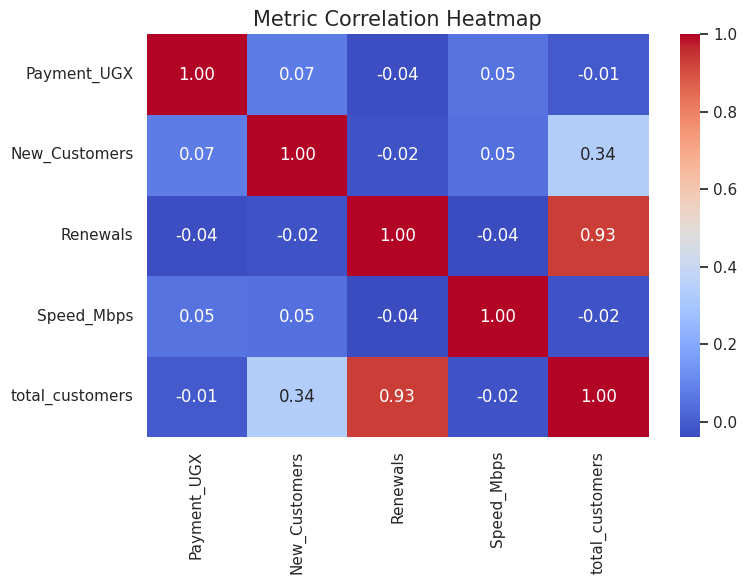

In [14]:
# Chart 11: Correlation Heatmap
plt.figure(figsize=(8, 6))
corr = df[['Payment_UGX', 'New_Customers', 'Renewals', 'Speed_Mbps', 'total_customers']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Metric Correlation Heatmap', fontsize=15)
plt.tight_layout()
plt.savefig('11_correlation_heatmap.png')
plt.show()

This heatmap displays the correlation coefficients between various key metrics like payment, new customers, renewals, speed, and total customers. Values closer to 1 or -1 indicate strong positive or negative correlations, respectively, helping to identify interdependencies. For example, 'New_Customers' and 'total_customers' show a strong positive correlation, which is expected, while other relationships might reveal less obvious insights.

This heatmap displays the correlation coefficients between various key metrics like payment, new customers, renewals, speed, and total customers. Values closer to 1 or -1 indicate strong positive or negative correlations, respectively, helping to identify interdependencies.

# 6. DASHBOARD OVERVIEW

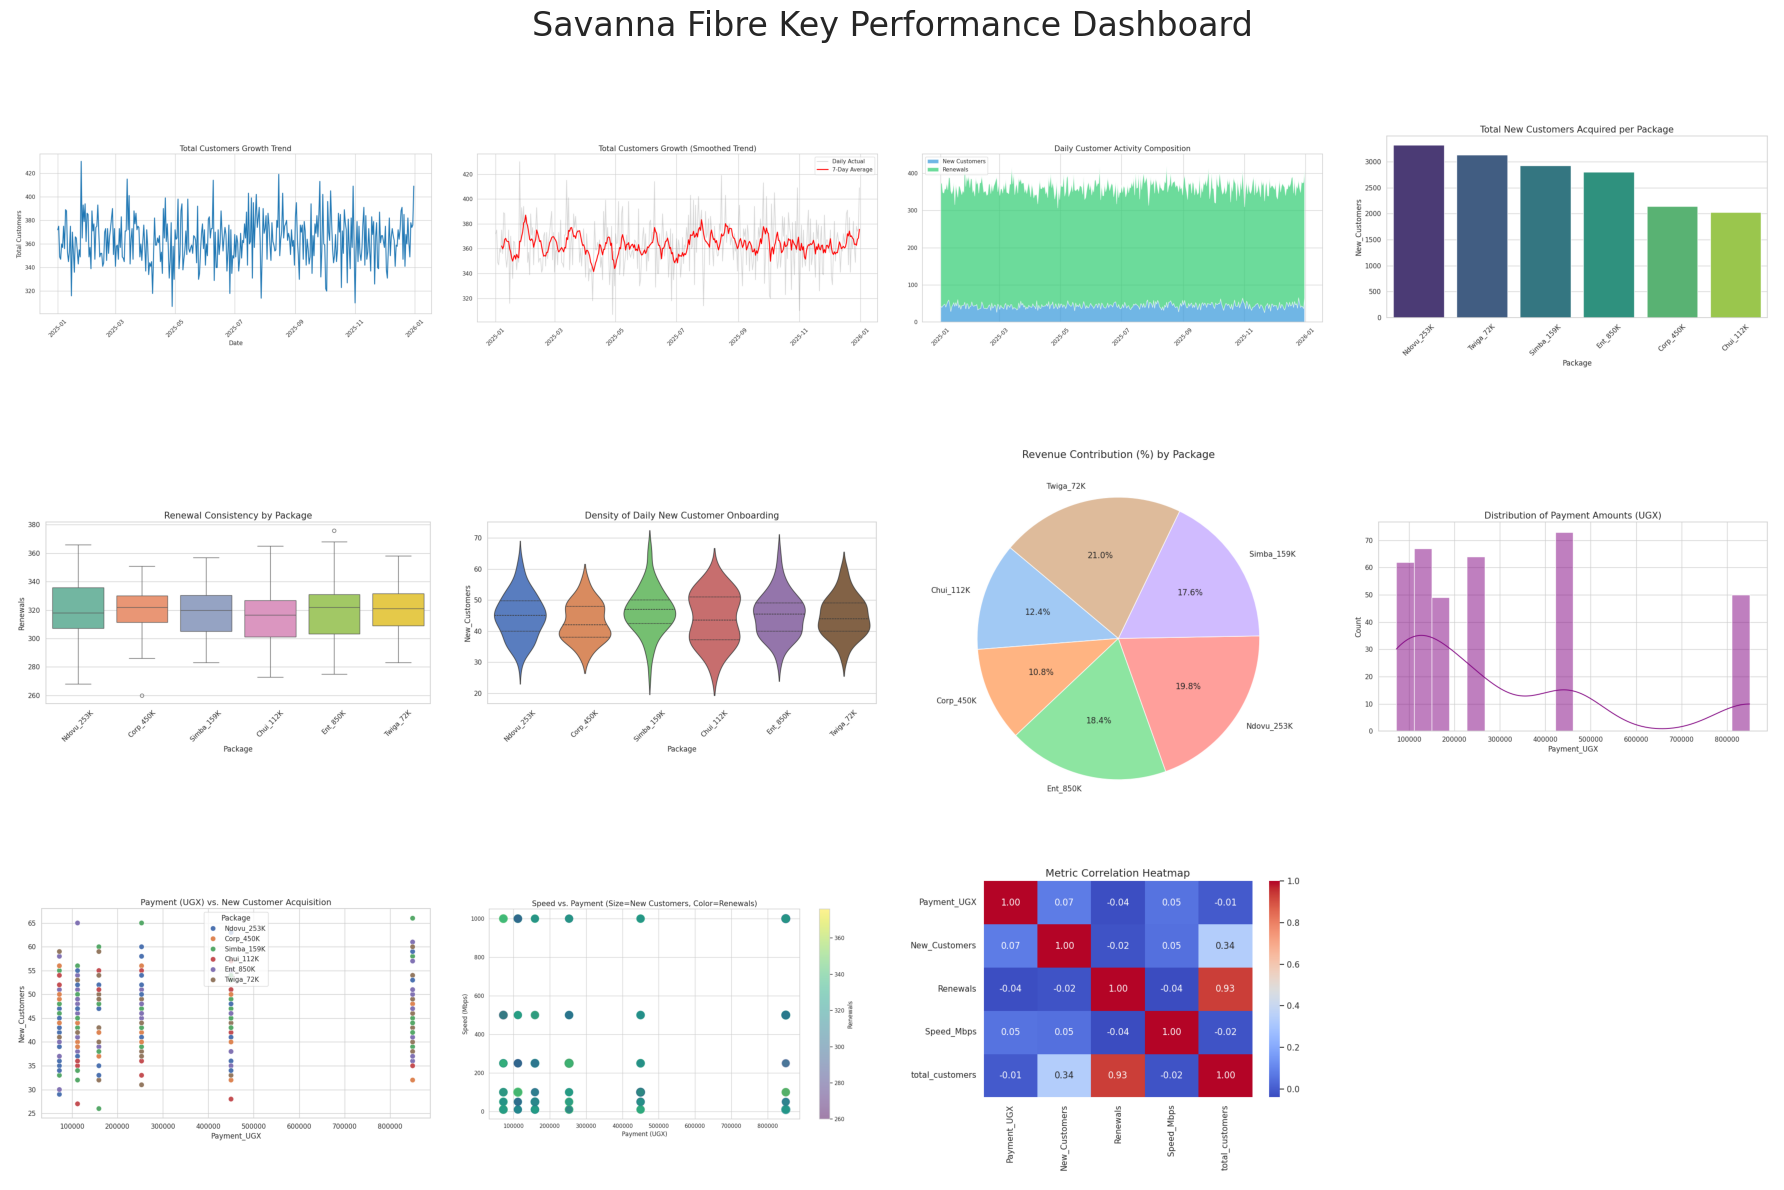

In [32]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# List of chart image filenames in order
chart_filenames = [
    '1_total_customers_trend.png',
    '2_total_customers_rolling.png',
    '3_stacked_activity.png',
    '4_new_customers_bar.png',
    '5_renewals_boxplot.png',
    '6_new_customers_violin.png',
    '7_revenue_pie.png',
    '8_payment_hist.png',
    '9_payment_vs_new_scatter.png',
    '10_bubble_analysis.png',
    '11_correlation_heatmap.png'
]

# Create a figure to hold all subplots
# Adjust figsize and grid based on the number of charts for a compact view
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(18, 12)) # Further adjusted figsize for compactness
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, filename in enumerate(chart_filenames):
    if i < len(axes):
        img = mpimg.imread(filename)
        axes[i].imshow(img)
        axes[i].axis('off') # Hide axes ticks

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle('Savanna Fibre Key Performance Dashboard', fontsize=24, y=1.02)
plt.show()